# Initial exploration of the Living Planet Database

This notebook is the starting point of the biodiversity analysis project.  
It introduces the Living Planet Database 2024 and checks whether the dataset is suitable for answering the main research question:

**Which vertebrate groups and world regions show the strongest population declines?**

At this stage, the goal is **not** to calculate trends or classify risk yet.  
Instead, this notebook focuses on understanding:

1. the structure of the dataset;
2. the main unit of analysis;
3. taxonomic, regional, ecosystem, and temporal coverage;
4. potential data-quality limitations that should be considered before trend calculation.

The following notebooks build on this exploration:

- `01_population_trend_calculation.ipynb` calculates population-level trends;
- `02_risk_analysis.ipynb` compares risk patterns across classes, ecosystems, and species summaries;
- `03_spatial_analysis.ipynb` examines where high-risk populations are geographically concentrated.


## 1. Load libraries and data

The analysis uses `pandas` for tabular data handling and `matplotlib` for simple exploratory visualizations.  
The raw Living Planet Database file is loaded from the `data/raw` folder.


In [1]:
# Import the libraries used in this notebook.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Show all columns when displaying pandas DataFrames.
pd.set_option("display.max_columns", None)

# Define the path to the raw Living Planet Database CSV file.
DATA_PATH = Path("../data/raw/LivingPlanetIndex_2024_PublicData/LPD_2024_public.csv")

# Load the raw dataset into a pandas DataFrame.
lpd = pd.read_csv(DATA_PATH)

# Display the first rows to confirm that the file loaded correctly.
lpd.head()


,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,Subspecies,Common_name,Location,Country,All_countries,Region,IPBES_region,IPBES_subregion,Latitude,Longitude,Specific_location,System,T_realm,T_biome,FW_realm,FW_biome,M_realm,M_ocean,M_biome,Units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,NaN,Grey-crowned crane,South-western Uganda,Uganda,Uganda,Africa,Africa,East Africa and adjacent islands,-0.07889,31.13306,0,Terrestrial,Afrotropical,"Tropical and subtropical grasslands, savannas ...",NaN,NaN,NaN,NaN,NaN,Mean number of counts per route,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.5,NaN,NaN,NaN,NaN,NaN,NaN,10.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,NaN,Seychelles warbler,"Cousin Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.33333,55.66667,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,Seychelles,Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.66667,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Total population number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0,41.0,NaN,NaN,21.0,24.0,NaN,NaN,NaN,NaN,NaN,17.0,NaN,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,Seychelles magpie-robin,"Fregate Island, Seychelles",Seychelles,Seychelles,Africa,Africa,East Africa and adjacent islands,-4.58333,55.93333,1,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.0,39.0,38.0,38.0,38.0,24.0,24.0,21.0,25.0,26.0,NaN,23.0,20.0,23.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,NaN,Mauritius kestrel,"Western Population, Mauritius",Mauritius,Mauritius,Africa,Africa,East Africa and adjacent islands,-20.30000,57.58333,0,Terrestrial,Afrotropical,Tropical and subtropical moist broadleaf forests,NaN,NaN,NaN,NaN,NaN,Number of breeding pairs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,2.0,4.0,4.0,7.0,7.0,7.0,9.0,8.0,9.0,13.0,14.0,22.0,26.0,40.0,52.0,58.0,61.0,NaN,NaN,NaN,NaN,NaN

## 2. Basic dataset structure

First, we check the overall shape of the dataset, the available columns, and their data types.  
This helps clarify what kind of information is available before any calculations are performed.


In [2]:
# Check the number of rows and columns in the dataset.
# Each row represents a monitored population record.
lpd.shape


(35996, 103)

In [3]:
# Display the column names to understand what variables are available.
lpd.columns.tolist()


['ID',
 'Binomial',
 'Replicate',
 'Included in LPR2024',
 'Citation',
 'Class',
 'Order',
 'Family',
 'Genus',
 'Species',
 'Subspecies',
 'Common_name',
 'Location',
 'Country',
 'All_countries',
 'Region',
 'IPBES_region',
 'IPBES_subregion',
 'Latitude',
 'Longitude',
 'Specific_location',
 'System',
 'T_realm',
 'T_biome',
 'FW_realm',
 'FW_biome',
 'M_realm',
 'M_ocean',
 'M_biome',
 'Units',
 '1950',
 '1951',
 '1952',
 '1953',
 '1954',
 '1955',
 '1956',
 '1957',
 '1958',
 '1959',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '20

In [4]:
# Inspect data types and non-null counts for all columns.
# This helps identify missing values and potential type issues.
lpd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35996 entries, 0 to 35995
Columns: 103 entries, ID to Unnamed: 102
dtypes: float64(74), int64(5), object(24)
memory usage: 28.3+ MB


## 3. Unit of analysis

The Living Planet Database is structured around **monitored populations**, not only species.  
This is important for the whole project: the main analysis should therefore be population-level.

Here we compare the number of:

- population records (`ID`),
- species names,
- binomial names.


In [5]:
# Count unique population IDs, species labels, and binomial names.
# This clarifies the main unit of analysis and the relationship between populations and species.
unit_summary = pd.DataFrame({
    "Metric": [
        "Unique population records (ID)",
        "Unique species names",
        "Unique binomial names"
    ],
    "Count": [
        lpd["ID"].nunique(),
        lpd["Species"].nunique(),
        lpd["Binomial"].nunique()
    ]
})

unit_summary


,Metric,Count
0,Unique population records (ID),35996
1,Unique species names,3736
2,Unique binomial names,5177


**Interpretation:**  
The number of population records is larger than the number of species because one species can be monitored in multiple locations or studies.  
For this reason, later trend and risk calculations use **population records** as the main analytical unit.


## 4. Taxonomic coverage

Next, we examine how many population records are available for each vertebrate class.  
This helps determine whether comparisons across classes are meaningful and whether some groups are underrepresented.


In [6]:
# Count the number of monitored population records per vertebrate class.
class_counts = (
    lpd["Class"]
    .value_counts(dropna=False)
    .rename_axis("Class")
    .reset_index(name="Population_Records")
)

class_counts


,Class,Population_Records
0,Aves,17834
1,Actinopteri,10081
2,Mammalia,5910
3,Reptilia,828
4,Amphibia,699
5,Elasmobranchii,591
6,Myxini,28
7,Holocephali,12
8,Petromyzonti,9
9,Dipneusti,3


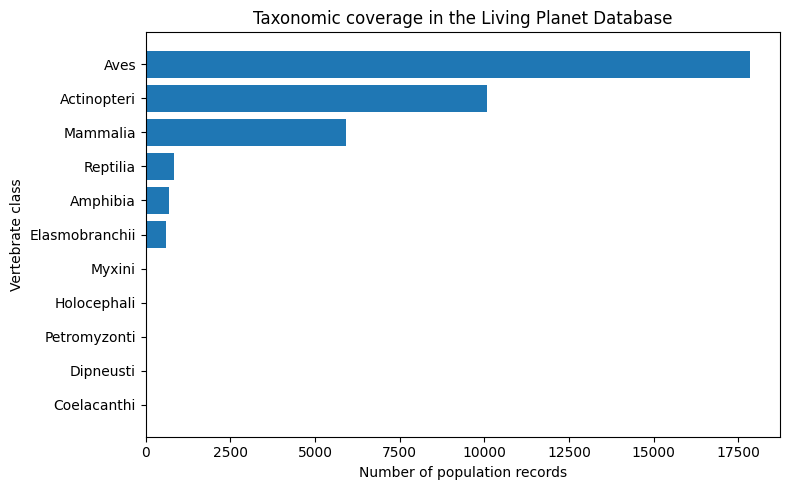

In [7]:
# Visualize taxonomic coverage by class.
# This is an exploratory count plot, not a trend or risk result.
class_counts_sorted = class_counts.sort_values("Population_Records", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(class_counts_sorted["Class"].astype(str), class_counts_sorted["Population_Records"])
plt.xlabel("Number of population records")
plt.ylabel("Vertebrate class")
plt.title("Taxonomic coverage in the Living Planet Database")
plt.tight_layout()
plt.show()


## 5. Regional and ecosystem coverage

The main research question includes world regions, so it is important to check how population records are distributed geographically and across ecosystems.

This section looks at:

- broad regions;
- IPBES regions;
- ecosystem systems.


In [8]:
# Count population records by broad region.
region_counts = (
    lpd["Region"]
    .value_counts(dropna=False)
    .rename_axis("Region")
    .reset_index(name="Population_Records")
)

region_counts


,Region,Population_Records
0,Oceania,11787
1,North America,8363
2,Latin America and Caribbean,5655
3,Europe,5175
4,Africa,2689
5,Asia,1922
6,Antarctic,237
7,International Waters,168


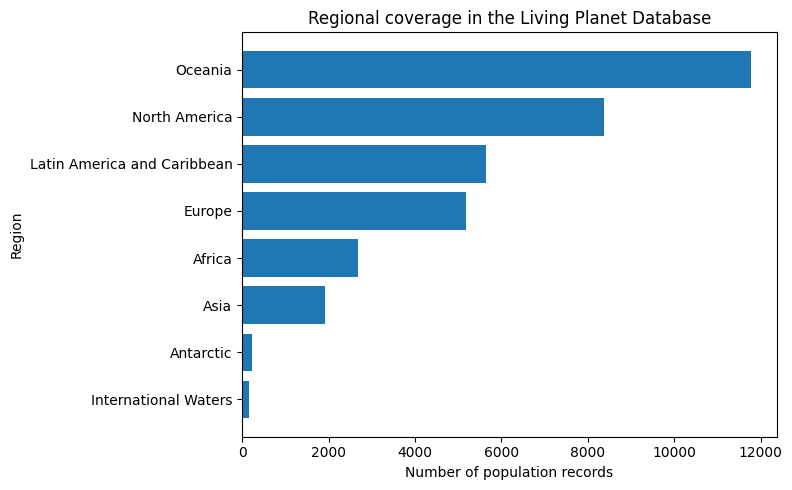

In [9]:
# Visualize broad regional coverage.
# This shows data availability, not population decline.
region_counts_sorted = region_counts.sort_values("Population_Records", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(region_counts_sorted["Region"].astype(str), region_counts_sorted["Population_Records"])
plt.xlabel("Number of population records")
plt.ylabel("Region")
plt.title("Regional coverage in the Living Planet Database")
plt.tight_layout()
plt.show()


In [10]:
# Count population records by IPBES region.
# IPBES regions provide an additional geographic grouping used in biodiversity reporting.
ipbes_counts = (
    lpd["IPBES_region"]
    .value_counts(dropna=False)
    .rename_axis("IPBES_region")
    .reset_index(name="Population_Records")
)

ipbes_counts


,IPBES_region,Population_Records
0,Americas,14117
1,Asia and the Pacific,13118
2,Europe and Central Asia,5757
3,Africa,2689
4,NaN,168
5,Antarctica,147


In [11]:
# Count population records by ecosystem system.
# This supports later comparisons between terrestrial, freshwater, and marine populations.
system_counts = (
    lpd["System"]
    .value_counts(dropna=False)
    .rename_axis("System")
    .reset_index(name="Population_Records")
)

system_counts


,System,Population_Records
0,Marine,16258
1,Terrestrial,11858
2,Freshwater,7880


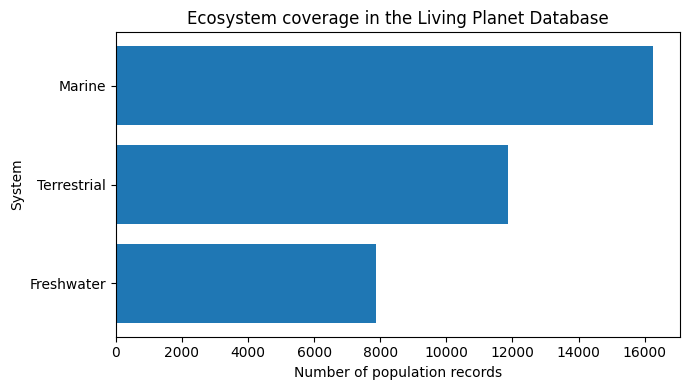

In [12]:
# Visualize ecosystem coverage.
# This helps show whether some systems have much more monitoring data than others.
system_counts_sorted = system_counts.sort_values("Population_Records", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(system_counts_sorted["System"].astype(str), system_counts_sorted["Population_Records"])
plt.xlabel("Number of population records")
plt.ylabel("System")
plt.title("Ecosystem coverage in the Living Planet Database")
plt.tight_layout()
plt.show()


## 6. Temporal coverage

Trend analysis requires population observations across years.  
The Living Planet Database stores annual abundance values in year columns.  
Here we identify those year columns and check the temporal coverage of the dataset.


In [13]:
# Identify columns that represent years.
# In this dataset, annual abundance columns are stored as column names such as "1970", "1971", etc.
year_columns = [
    col for col in lpd.columns
    if str(col).isdigit() and 1900 <= int(col) <= 2100
]

# Convert year column names to integers for easier summaries.
years = [int(col) for col in year_columns]

# Print a short summary of temporal coverage.
print("Number of year columns:", len(year_columns))
print("First year:", min(years))
print("Last year:", max(years))


Number of year columns: 71
First year: 1950
Last year: 2020


In [14]:
# Count how many non-missing abundance values exist for each year.
# This shows how monitoring coverage changes over time.
yearly_observation_counts = (
    lpd[year_columns]
    .notna()
    .sum()
    .rename_axis("Year")
    .reset_index(name="Observed_Populations")
)

yearly_observation_counts["Year"] = yearly_observation_counts["Year"].astype(int)

yearly_observation_counts.head()


,Year,Observed_Populations
0,1950,265
1,1951,245
2,1952,290
3,1953,285
4,1954,303


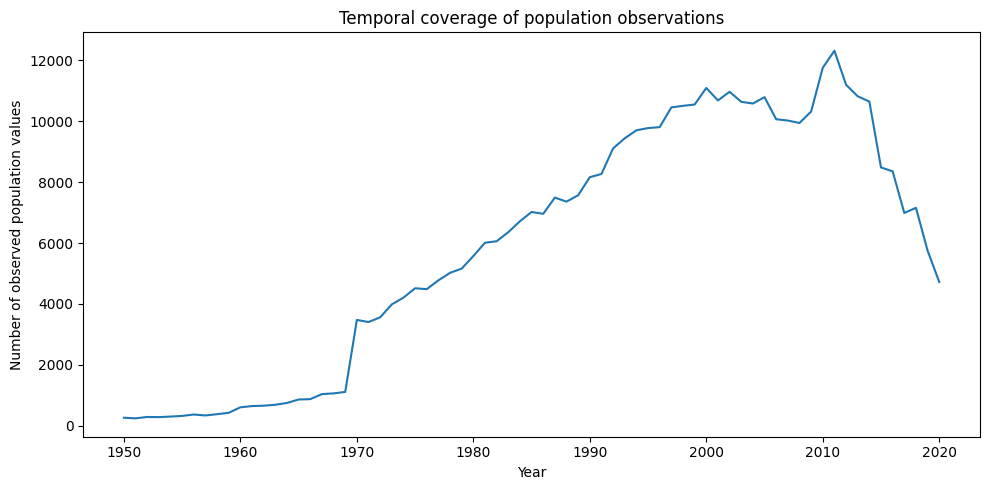

In [15]:
# Plot the number of observed population values by year.
# This is important because trend calculations are more reliable when temporal coverage is sufficient.
plt.figure(figsize=(10, 5))
plt.plot(
    yearly_observation_counts["Year"],
    yearly_observation_counts["Observed_Populations"]
)
plt.xlabel("Year")
plt.ylabel("Number of observed population values")
plt.title("Temporal coverage of population observations")
plt.tight_layout()
plt.show()


## 7. Missing values in key columns

Before calculating trends, we check missing values in variables that are important for later analysis:

- population ID;
- species and binomial names;
- class;
- system;
- region;
- coordinates.

This helps identify possible limitations for taxonomic and spatial analysis.


In [16]:
# Select key columns used across the project.
# Only columns that exist in the dataset are included, making this check robust to minor schema differences.
key_columns = [
    "ID",
    "Species",
    "Binomial",
    "Class",
    "System",
    "Region",
    "IPBES_region",
    "Latitude",
    "Longitude"
]

existing_key_columns = [col for col in key_columns if col in lpd.columns]

# Calculate missing values and missing percentages for key columns.
missing_summary = pd.DataFrame({
    "Column": existing_key_columns,
    "Missing_Values": [lpd[col].isna().sum() for col in existing_key_columns],
    "Missing_Percent": [lpd[col].isna().mean() * 100 for col in existing_key_columns]
})

missing_summary.sort_values("Missing_Percent", ascending=False)


,Column,Missing_Values,Missing_Percent
6,IPBES_region,168,0.466719
0,ID,0,0.000000
1,Species,0,0.000000
2,Binomial,0,0.000000
3,Class,0,0.000000
4,System,0,0.000000
5,Region,0,0.000000
7,Latitude,0,0.000000
8,Longitude,0,0.000000


## 8. Coverage across class and region

The main project question connects taxonomic groups and world regions.  
A cross-tabulation helps show whether all classes are represented across all regions or whether some combinations have limited data.


In [17]:
# Create a cross-tabulation of population records by class and region.
# This table shows data coverage for class-region combinations.
class_region_counts = pd.crosstab(
    lpd["Class"],
    lpd["Region"],
    dropna=False
)

class_region_counts


Region,Africa,Antarctic,Asia,Europe,International Waters,Latin America and Caribbean,North America,Oceania
Class,,,,,,,,
Actinopteri,461,19,353,949,109,3550,3806,834
Amphibia,33,0,32,85,0,241,279,29
Aves,888,199,895,3056,0,1156,2795,8845
Coelacanthi,1,0,0,0,0,0,0,0
Dipneusti,2,0,0,0,0,0,0,1
Elasmobranchii,66,6,21,46,52,65,288,47
Holocephali,0,0,0,0,0,2,9,1
Mammalia,1158,12,498,969,5,426,963,1879
Myxini,0,0,0,0,0,0,28,0


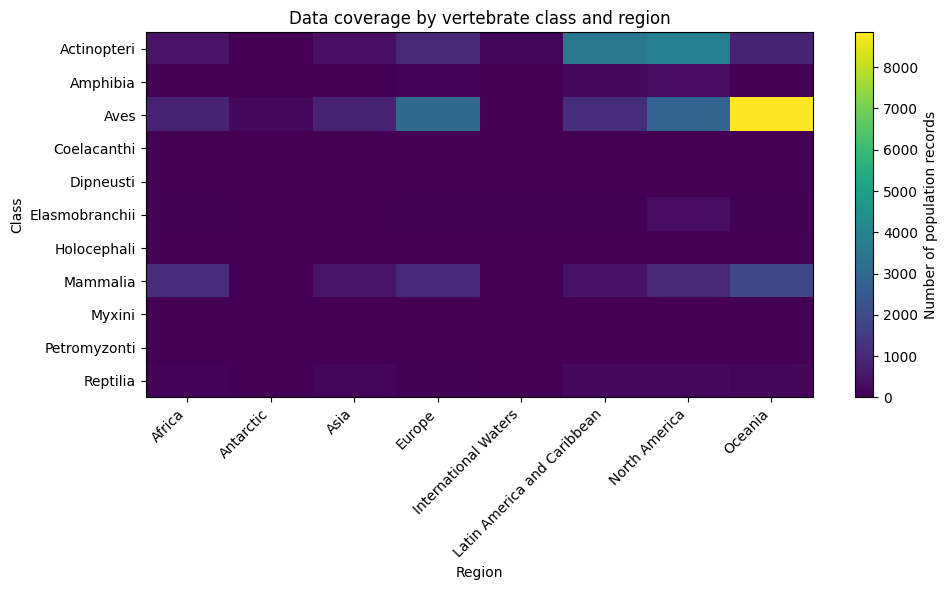

In [18]:
# Visualize class-region data coverage as a heatmap.
# This is a coverage heatmap, not a risk heatmap.
plt.figure(figsize=(10, 6))
plt.imshow(class_region_counts, aspect="auto")
plt.colorbar(label="Number of population records")
plt.xticks(
    range(len(class_region_counts.columns)),
    class_region_counts.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(class_region_counts.index)),
    class_region_counts.index
)
plt.xlabel("Region")
plt.ylabel("Class")
plt.title("Data coverage by vertebrate class and region")
plt.tight_layout()
plt.show()


## 9. Initial exploration summary

This initial exploration shows that the dataset is suitable for a population-level biodiversity trend analysis, but it also highlights important limitations:

- the main analytical unit is the monitored population record;
- population records are not evenly distributed across vertebrate classes;
- regional and ecosystem coverage is uneven;
- temporal coverage varies by year;
- spatial analysis depends on the availability of coordinates.

These observations guide the next notebook, where population-level trends are calculated only for populations with sufficient monitoring duration.


In [19]:
# Store a compact summary of basic dataset properties.
# This can be reused in the README or project presentation.
initial_summary = pd.DataFrame({
    "Metric": [
        "Rows / population records",
        "Columns",
        "Unique population IDs",
        "Unique species names",
        "Unique binomial names",
        "First observation year column",
        "Last observation year column"
    ],
    "Value": [
        lpd.shape[0],
        lpd.shape[1],
        lpd["ID"].nunique(),
        lpd["Species"].nunique(),
        lpd["Binomial"].nunique(),
        min(years),
        max(years)
    ]
})

initial_summary


,Metric,Value
0,Rows / population records,35996
1,Columns,103
2,Unique population IDs,35996
3,Unique species names,3736
4,Unique binomial names,5177
5,First observation year column,1950
6,Last observation year column,2020
